In [1]:
%matplotlib qt

import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. GENERATE MOCK DATA
# ==========================================
np.random.seed(42) # For reproducible results
n_samples = 1000
n_classes = 10

# Generate random 8x8 images (flattened into 64 pixels)
X_test = np.random.rand(n_samples, 64) 

# Generate random true labels (0-9)
y_true = np.random.randint(0, n_classes, n_samples)

# Generate slightly flawed random predictions (to create misclassifications)
# We make predictions mostly correct, but with some errors
y_pred = y_true.copy()
error_indices = np.random.choice(n_samples, size=int(n_samples * 0.15), replace=False)
for idx in error_indices:
    # Change to a random different class
    new_class = np.random.randint(0, n_classes)
    while new_class == y_true[idx]:
        new_class = np.random.randint(0, n_classes)
    y_pred[idx] = new_class

# Calculate the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

# ==========================================
# 2. DEFINE THE VISUALIZATION FUNCTIONS
# ==========================================

def show_misclassified_images(images):
    """
    Displays a grid of the misclassified images in a new window.
    """
    if len(images) == 0:
        return
    
    # Create a new figure for the images
    fig_images, axes = plt.subplots(figsize=(6, 6))
    axes.axis('off')
    
    # How many images to show? We'll limit to the first 16 for a clean grid
    n_to_show = min(len(images), 16)
    
    # Create a subplot grid
    rows = int(np.ceil(np.sqrt(n_to_show)))
    cols = int(np.ceil(n_to_show / rows))
    
    fig, axs = plt.subplots(rows, cols, figsize=(6, 6))
    fig.suptitle(f"Misclassified Images (Showing {n_to_show})", fontsize=14)
    
    # Flatten axes array for easy iteration
    axs_flat = axs.flatten()
    
    for i in range(n_to_show):
        # Reshape the 64-pixel array back into an 8x8 image
        img = images[i].reshape(8, 8)
        axs_flat[i].imshow(img, cmap='gray')
        axs_flat[i].axis('off')
    
    # Hide any unused subplots
    for j in range(n_to_show, len(axs_flat)):
        axs_flat[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. SETUP THE CLICKABLE CONFUSION MATRIX
# ==========================================

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(cm, cmap='Blues')

# Formatting the matrix
plt.title('Clickable Confusion Matrix', pad=20)
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.xticks(range(n_classes), range(n_classes))
plt.yticks(range(n_classes), range(n_classes))

# Add text annotations to the cells
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

def onclick(event):
    # Check if click was inside the matrix axis
    if event.inaxes == ax:
        # Convert mouse coordinates to integer grid coordinates
        # Note: matshow puts (0,0) at top-left, so xdata = col, ydata = row
        col = int(round(event.xdata))
        row = int(round(event.ydata))
        
        # Ensure we didn't click outside the 0-9 grid
        if 0 <= row < n_classes and 0 <= col < n_classes:
            
            # Filter the data based on the click (row = actual, col = predicted)
            indices = np.where((y_true == row) & (y_pred == col))[0]
            
            # Clear any previous highlighting
            for text in ax.texts:
                text.set_color('black')
            ax.patches.clear()
            
            # Highlight the clicked cell with a red border
            rect = plt.Rectangle((col - 0.5, row - 0.5), 1, 1, fill=False, edgecolor='red', linewidth=3)
            ax.add_patch(rect)
            
            # If there are misclassifications, show them
            if len(indices) > 0:
                print(f"Clicked: Actual={row}, Predicted={col}. Found {len(indices)} errors.")
                show_misclassified_images(X_test[indices])
            else:
                print(f"Clicked: Actual={row}, Predicted={col}. No images found for this cell.")
            
            fig.canvas.draw()

# Bind the click event to the matrix
fig.canvas.mpl_connect('button_press_event', onclick)

print("RUNNING DEMO:")
print("Click on ANY non-diagonal cell (e.g., row 9, col 4) to see misclassified images pop up.")
plt.show()

ImportError: Failed to import any of the following Qt binding modules: PyQt6, PySide6, PyQt5, PySide2

READY: Click on any non-diagonal cell (e.g. row 2, col 5).


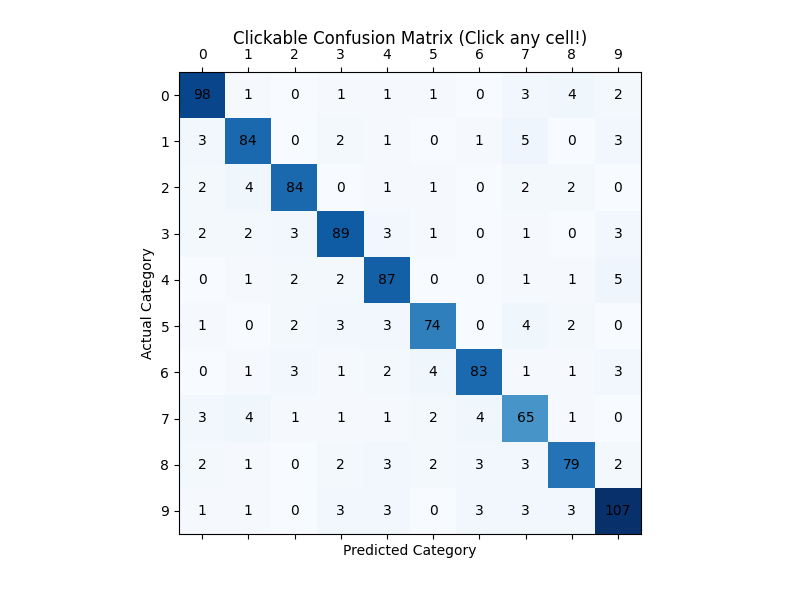

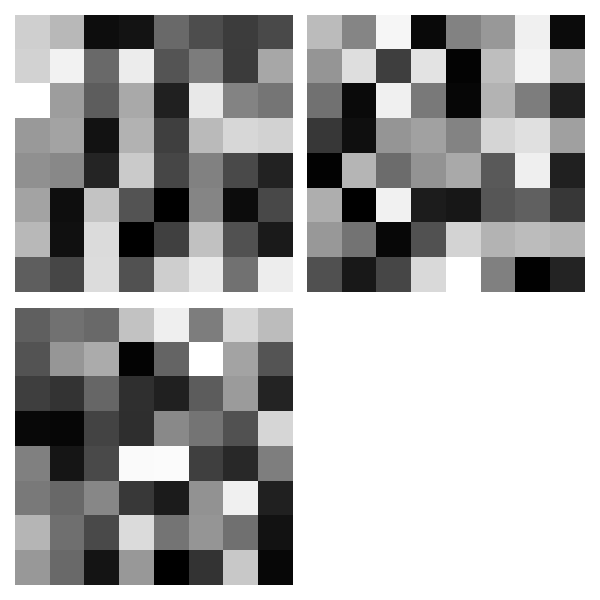

AttributeError: 'Axes' object has no attribute 'flatten'

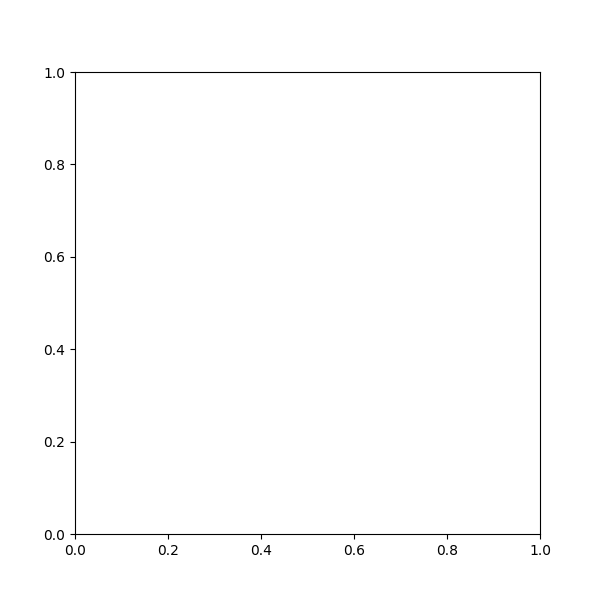

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. GENERATE MOCK DATA
# ==========================================
np.random.seed(42)
n_samples = 1000
n_classes = 10

# Mock images (8x8 pixels)
X_test = np.random.rand(n_samples, 64) 

# Mock labels
y_true = np.random.randint(0, n_classes, n_samples)
y_pred = y_true.copy()

# Introduce some random errors
error_indices = np.random.choice(n_samples, size=int(n_samples * 0.15), replace=False)
for idx in error_indices:
    new_class = np.random.randint(0, n_classes)
    while new_class == y_true[idx]:
        new_class = np.random.randint(0, n_classes)
    y_pred[idx] = new_class

cm = confusion_matrix(y_true, y_pred)

# ==========================================
# 2. SETUP THE INTERACTIVE PLOT INSIDE VS CODE
# ==========================================
# This magic command activates the interactive backend inside VS Code
%matplotlib widget 

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(cm, cmap='Blues')

ax.set_title('Clickable Confusion Matrix (Click any cell!)', pad=20)
ax.set_xlabel('Predicted Category')
ax.set_ylabel('Actual Category')
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))

# Add numbers to the cells
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

# ==========================================
# 3. DEFINE THE CLICK EVENT
# ==========================================
def onclick(event):
    # Clear previous highlights
    for patch in ax.patches:
        patch.remove()
    
    # Check if click was inside the matrix
    if event.inaxes == ax:
        col = int(round(event.xdata))
        row = int(round(event.ydata))
        
        # Ensure we are inside the 0-9 grid
        if 0 <= row < n_classes and 0 <= col < n_classes:
            
            # Highlight the clicked cell with a red box
            rect = plt.Rectangle((col - 0.5, row - 0.5), 1, 1, fill=False, edgecolor='red', linewidth=3)
            ax.add_patch(rect)
            fig.canvas.draw()
            
            # Find the misclassified images
            indices = np.where((y_true == row) & (y_pred == col))[0]
            
            if len(indices) > 0:
                print(f"\n>> Clicked: Actual={row}, Predicted={col}. Found {len(indices)} images.")
                
                # Show up to 12 images
                n_to_show = min(len(indices), 12)
                rows = int(np.ceil(np.sqrt(n_to_show)))
                cols = int(np.ceil(n_to_show / rows))
                
                # Create a NEW pop-up window for the images
                fig_img, axs = plt.subplots(rows, cols, figsize=(6, 6))
                fig_img.canvas.manager.set_window_title(f"Misclassified (Actual {row} -> Predicted {col})")
                
                axs_flat = axs.flatten()
                for i in range(n_to_show):
                    img = X_test[indices[i]].reshape(8, 8)
                    axs_flat[i].imshow(img, cmap='gray')
                    axs_flat[i].axis('off')
                
                # Hide empty subplots
                for j in range(n_to_show, len(axs_flat)):
                    axs_flat[j].axis('off')
                    
                plt.tight_layout()
                plt.show()
            else:
                print(f"\n>> Clicked: Actual={row}, Predicted={col}. No images found here.")

# Bind the click event
fig.canvas.mpl_connect('button_press_event', onclick)

print("READY: Click on any non-diagonal cell (e.g. row 2, col 5).")
plt.show()

In [ ]:
# !pip install ipympl